# <center>VAI Academy</center>

# <center>Análise Exploratória de Dados</center>
___

# <center> Objetivos de aprendizado </center>
- Entender a importância e a aplicação de uma EDA (Exploratory Data Analysis)
- Ser capaz de implementar diferentes tipos de visualizações de dados para apoiar as análises
- Adquirir senso crítico em relação à utilização das diferentes técnicas de EDA
___


## Conteúdo
1. [Introdução](#intro) <br>
2. [Sumarização de Dados](#sum) <br>
3. [Visualização de Dados](#dat) <br>
4. [Vá Além](#digdeeper)


<a id="dsprecap"></a>
## Recapitulando: Data Science Pipeline (DSP)
1. Entendimento do Problema / Definição de Escopo
2. Definição de Objetivo e Configuração de Métricas
3. Determinação dos Dados Necessários
4. Aquisição de Dados
5. Limpeza de Dados & Manipulação
6. Análise Exploratória de Dados (E.D.A.)
7. Engenharia de Atributos
8. Construção e Avaliação do Modelo
9. Interpretação de Resultados & Relatório / Data Storytelling
10. Implantação
11. Monitoramento e Manutenção

Esta aula é sobre a **etapa 6**. Já estamos na metade do caminho \o/.

# Antes de seguir com esse notebook!

Recomendamos que assista ao video deste módulo.

In [1]:
from IPython.display import HTML

HTML('''
<iframe width="640" height="360"
    src="https://www.youtube.com/embed/VTtl-VJZqgs"
    frameborder="0"
    allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture"
    referrerpolicy="strict-origin-when-cross-origin"
    allowfullscreen>
</iframe>
''')

<a id="intro"></a>
## 1. Introdução

O objetivo principal da etapa de Análise Exploratória de Dados (ou, do inglês *Exploratory Data Analysis* - EDA) é reunir *insights* (percepções) e informações relevantes a partir da estruturação dos dados. Trata-se de uma etapa prévia ao desenvolvimento de um modelo, que agrega valor à análise através de um entendimento mais profundo das variáveis que compõem a base de dados e as associações que existem entre elas.

EDA é um procedimento interativo que deve ser direcionado por algumas perguntas, relevantes ao contexto da análise, onde se espera entender melhor o fenômeno representado pelos dados e inclusive obter respostas para algum desses questionamentos. A beleza do EDA está no fato de que você não sabe exatamente onde irá chegar. Entretanto, ao indagar seus dados, você acaba entendendo melhor o que está acontecendo e, por ventura, conseguirá realizar um trabalho melhor com essas novas informações.

Vamos agora procurar alguns *insights* nos conjuntos de dados com que trabalharemos nesta aula.

### Base de dados: Iris

Este é provavelmente um dos conjuntos de dados *training wheels* (aprendendo a andar com as rodinhas da bicicleta) mais conhecidos. É um conjunto de dados simples e pequeno, comumente usado pela comunidade de ciência de dados como exemplo para a aplicação de algumas técnicas.

O estudo que gerou essa base tinha como objetivo buscar por características físicas de uma flor que permitissem classificar suas diferentes espécies. Nesta aula iremos repetir alguns dos passos dessa análise, ou seja, buscaremos, na estrutura dos dados, possíveis maneiras de diferenciar cada exemplar dessa flor.

Aqui podemos observar quatro características escolhidas para tentar determinar se uma flor é *setosa*, *versicolor* ou *virginica*: comprimento e largura da sépala (cálice da flor), comprimento e largura da pétala.

Perguntas que podem direcionar a EDA:

*   O tamanho das estruturas da flor podem definir sua espécie?
*   Exemplares com pétalas maiores terão sépalas também maiores? ou será o contrário?


<center><img src="https://cdn-images-1.medium.com/freeze/max/1000/1*gwmXliaxIBkY4NQBhoe9JQ.png?q=20" width="600"></center>




<a id="sum"></a>
## 2. Sumarização dos Dados


Quando se deseja medir algo, geralmente é necessário fazer várias medições. Isso ocorre porque geralmente as variáveis usadas para descrever comportamentos - como o nome já diz - têm caráter variável. Assim, são necessários vários resultados para se construir uma compreensão da situação.

Recolhidas essas medidas, é necessário [resumi-las](https://pt.wikipedia.org/wiki/S%C3%ADntese_estat%C3%ADstica) de alguma forma, pois conjuntos contendo dados brutos não são facilmente interpretáveis.

Portanto, antes de plotar (construir gráficos) e tentar fazer qualquer análise, é crucial entender o conjunto de dados com o qual você está trabalhando.

Para fazer isso, algumas informações importantes que devemos procurar são:
1. Dimensão dos dados
2. Tipo dos dados de cada variável (datatype)
3. Estatísticas do conjunto de dados (média, mediana, moda)
4. Valores nulos

Sendo assim, antes de obter qualquer *insight*, você precisa primeiro examinar seu conjunto de dados.

In [2]:
# ATENÇÃO:  Após instalar as bibliotecas reinicie o ambiente de execução para garantir que está usando a versão correta
#!pip install pandas==1.5.3
#!pip install matplotlib==3.7.1
#!pip install seaborn==0.12.2

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# carregamento do dataset localizado no diretório "dados/"
iris = pd.read_csv('dados/Iris.csv') # a base de dado iris agora é um dataframe do Pandas

iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [4]:
# explorando a base
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [5]:
# dimensões do dataframe
iris.shape

(150, 5)

In [6]:
# estatísticas da base (média, mediana, desvio padrão)
iris.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [7]:
# verificação da presença de valores nulos na base
iris.isnull().sum()

,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


<a id="dat"></a>

## 3. Visualização de Dados

Agora que temos uma ideia do que são nossos dados, podemos começar a explorá-los. Para isso, a maneira mais fácil e elegante é a visualização a partir de *plots*. Talvez vocês tenham visto alguns *plots* em aulas anteriores, mas agora vamos nos aprofundar.

Para isso, mostraremos alguns gráficos, com seu uso e código, em análises uni variadas e multivariadas.

Serão utilizadas para a construção dos gráficos o método [plot](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html) do pandas e o pacote [seaborn](https://seaborn.pydata.org/). Em caso de dúvidas sobre o comportamento dos métodos gráficos ou da utilização de algum atributo específico é interessante desenvolver o hábito de consultar a documentação oficial.

### 3.1 Análise Univariada
Os gráficos uni variados são usados para entender como cada variável se comporta independentemente das outras. Alguns exemplos são *boxplots*, histogramas e gráficos de barras.

#### 3.1.1 Boxplot
Boxplots são usados para ver a distribuição de uma variável, adequado para variáveis numéricas, mostrando informações como a mediana, quartis e até outliers! Basta usar ```plot``` com o argumento ```kind = 'box'```. Também adicionamos os argumentos ```figsize```, ```subplots``` e ```layout``` para ajustá-los como quisermos. Brincaremos com esses parâmetros para ver como eles funcionam!




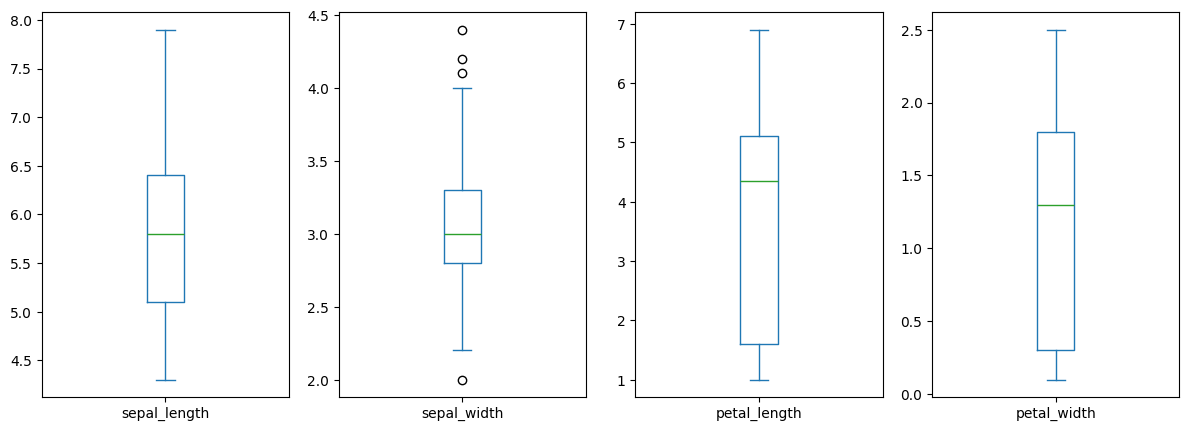

<Figure size 640x480 with 0 Axes>

In [8]:
iris.plot(kind='box', figsize=(30, 5), subplots=True, layout=(1, 8))
_ = plt.figure()

Consegue interpretar esses ```boxplots```? Se não, busque relembrar os [conceitos](https://en.wikipedia.org/wiki/Box_plot) de estatística!

#### 3.1.2. Histogramas
O histograma é uma ferramenta de visualização da distribuição de frequências das variáveis numéricas. Nesta visão, são criados diferentes subintervalos de valores, cada um agrupando as medidas em uma faixa de números. Assim conseguimos ter uma boa noção de onde os valores estão localizados.

Plotaremos abaixo o histograma para analisar todas as variáveis de uma vez:




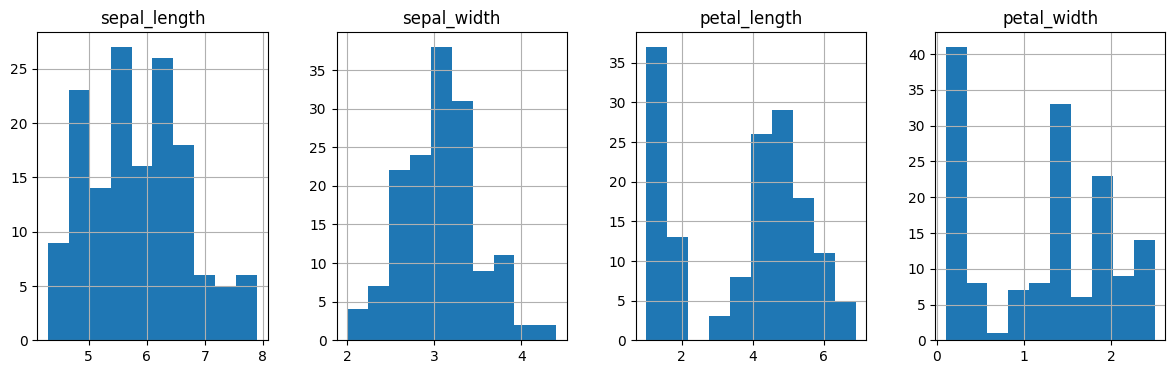

<Figure size 640x480 with 0 Axes>

In [9]:
iris.hist(figsize=(30,4), layout=(1,8))
_ = plt.figure()

Consegue adivinhar a distribuição da variável ```sepal_width``` a partir desse *plot*? Parece uma distribuição normal, não é?

#### 3.1.3. Estimativa de Densidade Kernel (KDE)
A Estimativa de Densidade Kernel (*Kernel Density Estimation* - KDE), estima a função de densidade de probabilidade de uma variável. Isso é feito ao desenhar uma curva contínua (o kernel, geralmente uma gaussiana) para cada ponto. Todas as curvas são somadas para formar uma única estimativa de densidade suave. No final, ela se parece com uma versão suavizada dos histogramas.

Caso tenha interesse em aprofundar o entendimento da curva KDE :

[Histograms vs. KDEs Explained](https://towardsdatascience.com/histograms-vs-kdes-explained-ed62e7753f12)




<Figure size 640x480 with 0 Axes>

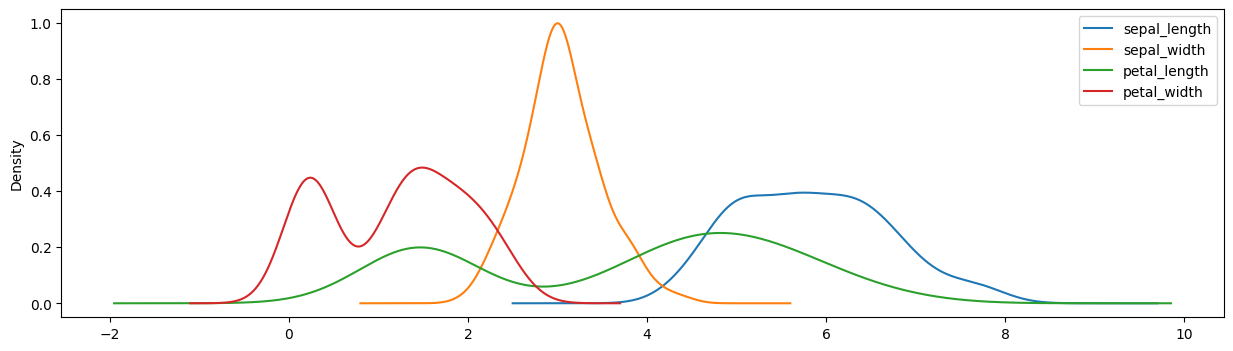

<Figure size 640x480 with 0 Axes>

In [10]:
iris.plot(kind='kde', figsize=(15, 4), subplots=False, layout=(1, 8))
plt.figure()

Tire um momento para comparar o ```KDE``` com o histograma (se atente a ordem em que as variáveis são apresentadas). Eles não são exatamente iguais, mas ainda podemos fazer algumas suposições sobre eles, tendo uma vantagem que iremos discutir depois.

#### 3.1.4. Gráficos de Barras
Os gráficos de barras são muito semelhantes aos histogramas. A diferença é que o gráfico de barras é usado com dados categóricos, tendo uma barra para cada categoria. Vamos dar uma olhada na distribuição de nossa variável ```species``` usando gráficos de barras.




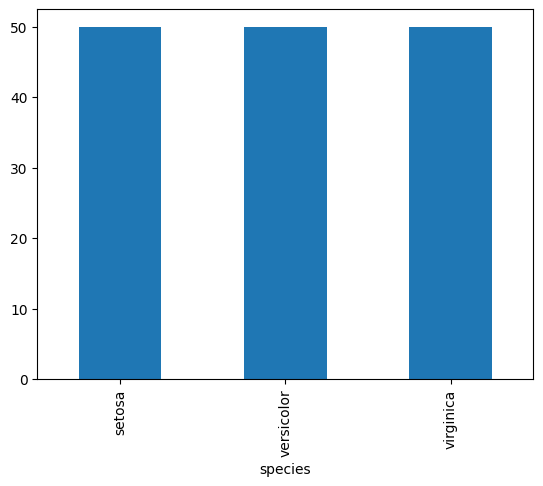

In [11]:
iris['species'].value_counts().plot(kind="bar");

Três barras idênticas! Isso ocorre por nossos dados serem distribuídos igualmente entre essas três espécies, são cinquenta registros para cada uma.

### 3.2. Análise Multivariada
Uma vez feitos os gráficos das análises uni variadas, devemos ter um bom entendimento de como cada variável age por si mesma. Em ciência de dados, geralmente queremos entender como uma variável se relaciona com outra. Por exemplo, a temperatura influencia a quantidade de sorvete consumido na praia? Se isso acontecer, como isso pode influenciar o trabalho de quem vende sorvete na praia? O consumo de sorvete cresce assim como a temperatura? Ele cresce na proporção de 1:1?

Todos esses tipos de perguntas são respondidas com análise multivariável, o que pode ser feito com gráficos multivariáveis. Vamos dar uma olhada em alguns deles.

#### 3.2.1. Gráfico de dispersão
O gráfico de dispersão mostra cada registro como um ponto no gráfico, tendo um eixo para cada variável. Por exemplo, poderíamos perguntar como o comprimento da sépala se relaciona com a largura da sépala.




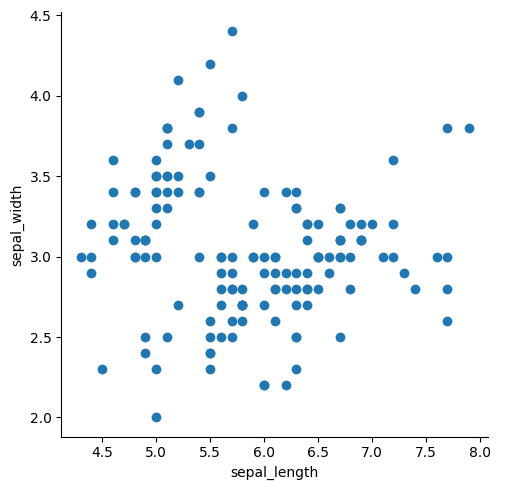

In [12]:
sns.FacetGrid(iris, height=5) \
   .map(plt.scatter, "sepal_length", "sepal_width") \
   .add_legend()

plt.show()

Aparentemente, não há correlação óbvia entre altura e largura da sépala. E se pudéssemos adicionar outra informação, como as espécies? Como cada ponto no gráfico é um registro e cada registro é relacionado a uma espécie, podemos colori-los correspondentemente, adicionando outra informação ao nosso gráfico.

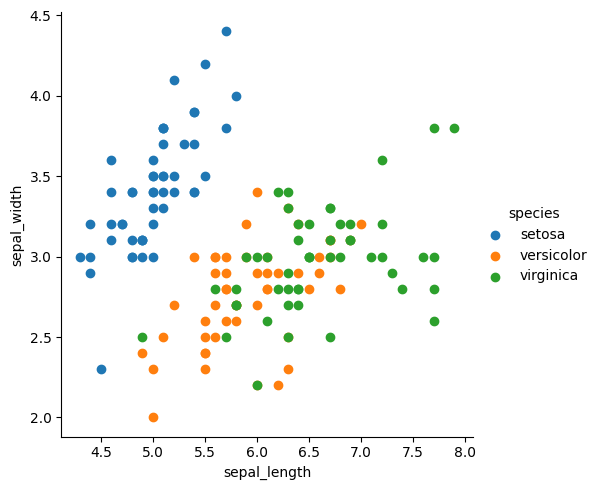

In [13]:
sns.FacetGrid(iris, hue="species", height=5) \
   .map(plt.scatter, "sepal_length", "sepal_width") \
   .add_legend()

plt.show()

Consegue ver a diferença? Agora podemos ver claramente que Setosas são diferentes das outras em termos da correlação entre altura e largura da sépala. Isso torna possível discernir quase completamente essas espécies das outras com um limite de uma linha reta.

No entanto, separar Versicolor de Viginica é muito mais difícil, pois elas têm uma sobreposição considerável.

#### 3.2.2. Boxplot
Espere, não acabamos de ver o boxplot como um gráfico uni variável? Você está totalmente certo! Um boxplot é, de fato, um gráfico que mostra apenas um tipo de informação. Podemos ver as relações entre uma variável numérica e uma categórica usando diversos boxplots, um para cada categoria, plotando os dados numéricos. Podemos tentar visualizar o comprimento da pétala para cada espécie com isso.




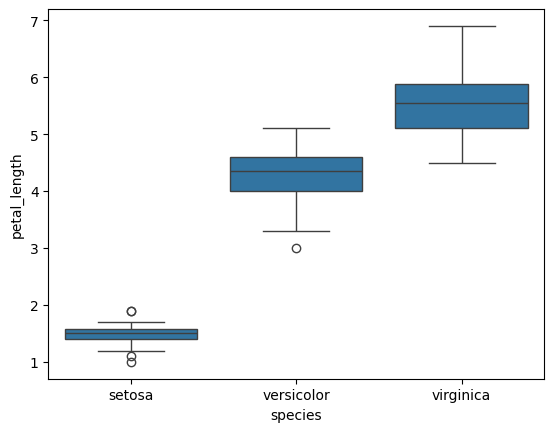

In [14]:
sns.boxplot(x="species", y="petal_length", data=iris)
plt.show()

Isso deixa mais claro que as espécies diferem no comprimento das pétalas, principalmente para as Setosas do que para Versicolor e a Virginica.

#### 3.2.3. Estimativa de Densidade Kernel (KDE)
Mais uma vez, um tipo de gráfico que apresentamos anteriormente para análise uni variada. Assim como fizemos com os boxplots, podemos combinar o KDE com as espécies para ver como elas se contrastam. Essa é a vantagem sobre os histogramas sobre os quais falamos anteriormente. Imagine ter que comparar barras sobrepostas de diferentes histogramas. Isso não seria fácil. Em vez disso, usamos o KDE, semelhante a um histograma, mas pode ser sobreposto, pois, é apenas uma linha.




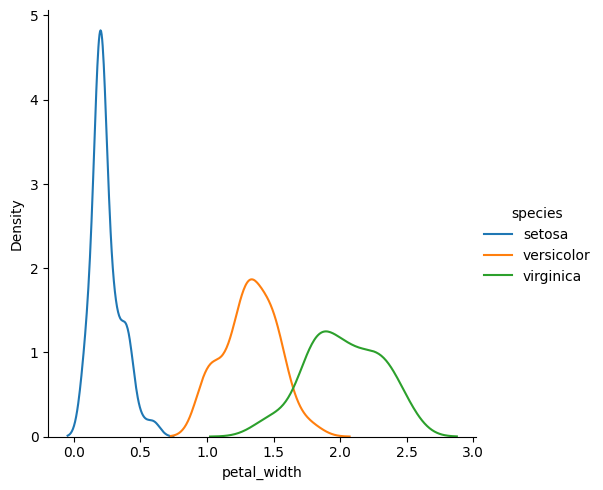

In [15]:
sns.FacetGrid(iris, hue="species", height=5).map(sns.kdeplot, "petal_width").add_legend()
plt.show()

#### 3.2.4. Plot matrix
A biblioteca ```pandas``` facilita a análise multivariável de todas as variáveis, duas a duas. É o que chamamos de *plot matrix*. Por exemplo, poderíamos usar o pandas para produzir um gráfico de dispersão para cada par de variáveis, como mostrado abaixo.

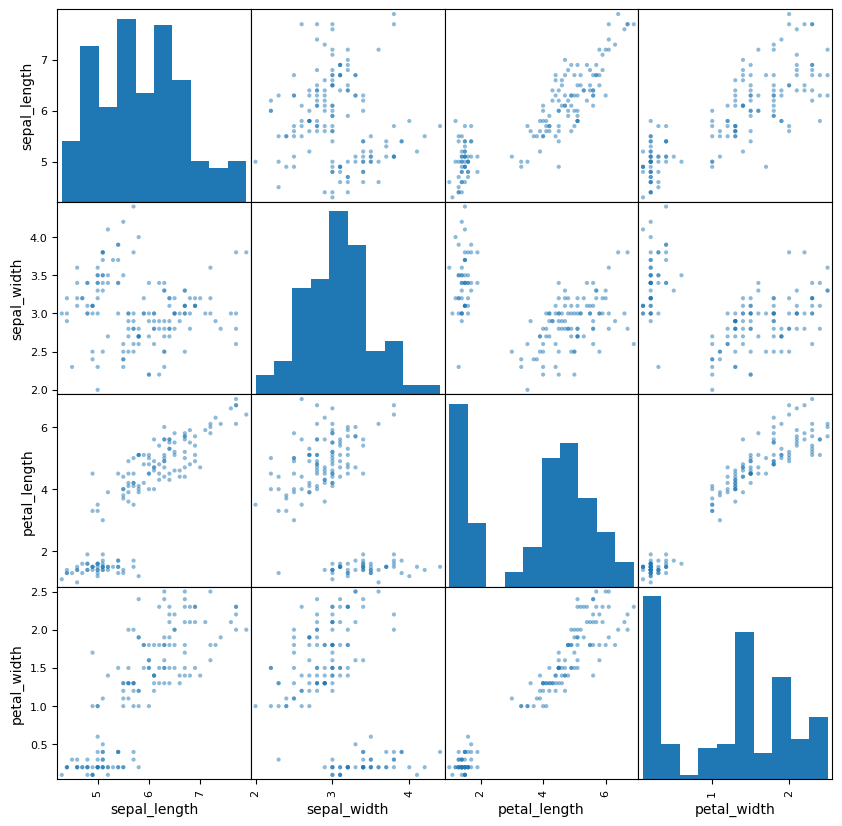

In [16]:
pd.plotting.scatter_matrix(iris, figsize=(10,10))
plt.show()

Esse é um belo gráfico! Podemos analisar todos os pares de variáveis de uma só vez. Por exemplo, podemos ver que ```petal_length``` e ```petal_width```, parecem altamente correlacionados, enquanto ```sepal_length``` e ```sepal_width```, não.

Mas podemos melhorar isso ainda mais com a biblioteca *seaborn*. Ela permite atribuir cores às espécies e alterar o gráfico de variável única. Veja o exemplo abaixo.

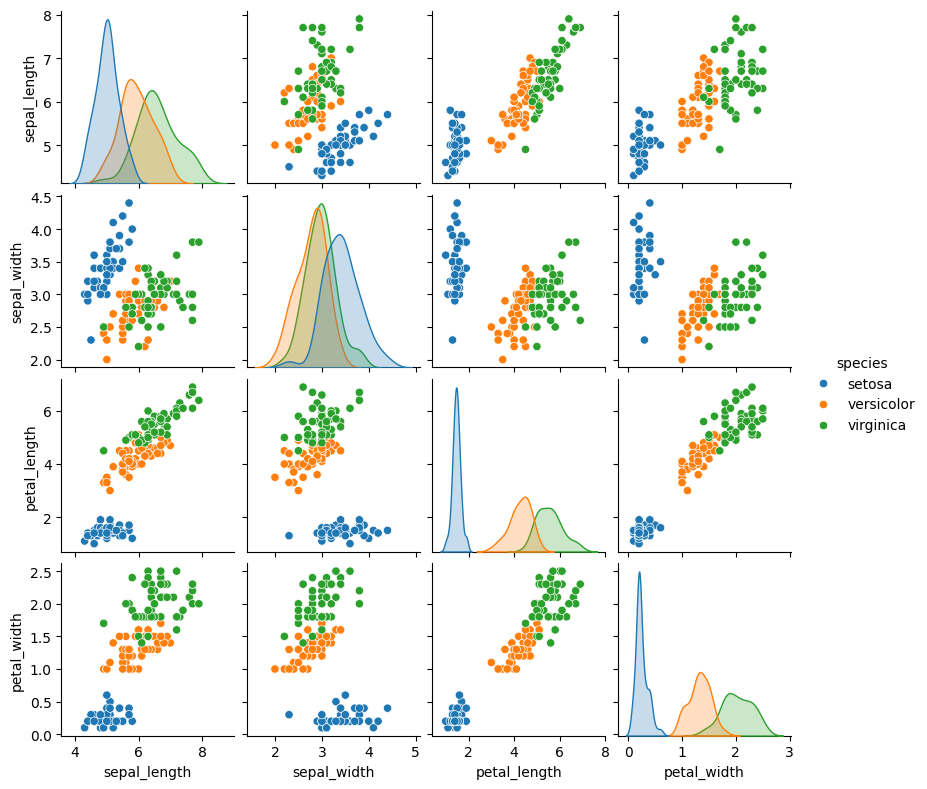

In [17]:
_ = sns.pairplot(iris, hue="species", height=2, diag_kind="kde")

Muito melhor! Podemos ver que Setosa se comporta de maneira diferente para todos os pares de variáveis, o que significa que seria possível isolá-los das outras espécies usando qualquer par de variáveis. Isso não pode ser dito para Versicolor e Virginica, especialmente para o par de variáveis altura e largura da sépala.

#### 3.2.5. Mapa de Calor de Correlação
Os mapas de calor de correlação também são conhecidos como matrizes de correlação. Eles representam a correlação para cada par de variáveis, facilitando a visualização de todas as relações existentes entre as variáveis.

Aqui faremos um pouco diferente do exemplo feito na aula de estatística, usaremos o ```seaborn``` para simplificar.




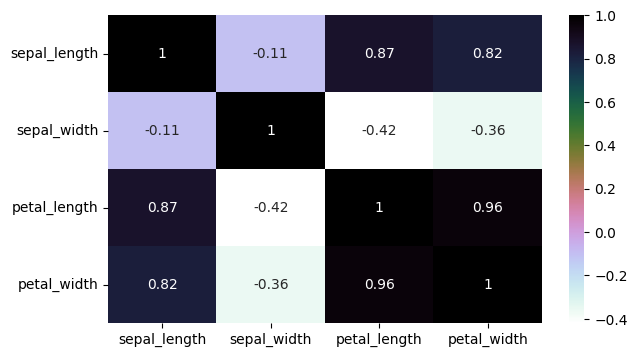

In [18]:
corr = iris.drop('species', axis=1).corr()

plt.figure(figsize=(7, 4))
sns.heatmap(corr, annot=True, cmap='cubehelix_r')
plt.show()

Já tínhamos uma boa visão geral dessas correlações dos gráficos anteriores, mas agora podemos confirmar que a altura e a largura da sépala quase não estão correlacionadas, enquanto a altura e a largura da pétala estão quase perfeitamente correlacionadas.

##### Insights
* ```petal_length``` e ```petal_width``` são as variáveis mais importantes para identificar vários tipos de flores.

* Embora a Setosa possa ser facilmente identificada (linearmente separável), Virginica e Versicolor mostram alguma sobreposição (maior dificuldade de separação com uma linha).

<a id="digdeeper"></a>
## Vá Além (Opcional)

Leia os artigos abaixo. Eles irão complementar os assuntos abordados na aula e ajudarão a entender algumas aplicações de EDA.

* [What is Exploratory Data Analysis?](https://towardsdatascience.com/exploratory-data-analysis-8fc1cb20fd15)
* [Plot With Pandas: Python Data Visualization for Beginners](https://realpython.com/pandas-plot-python/)
* [How to Pick the Right Chart Type?](https://eazybi.com/blog/data-visualization-and-chart-types)
* [Storytelling com Dados](https://www.amazon.com.br/Storytelling-com-Dados-Visualiza%C3%A7%C3%A3o-Profissionais/dp/8550804681/ref=asc_df_8550804681/?tag=googleshopp00-20&linkCode=df0&hvadid=379805395634&hvpos=&hvnetw=g&hvrand=824525941124359361&hvpone=&hvptwo=&hvqmt=&hvdev=c&hvdvcmdl=&hvlocint=&hvlocphy=1031759&hvtargid=pla-812777209198&psc=1)
* [Datacamp | EDA Course](https://www.datacamp.com/courses/exploratory-data-analysis)

<a id="pan"></a>
## Fim da Aula!
Com a conclusão desta aula, esperamos que você tenha aumentado seu repertorio de técnicas para fazer uma boa EDA!
Certifique-se de tirar todas suas dúvidas conosco!

Até a próxima aula!!